<a href="https://colab.research.google.com/github/sarkarshrayan2-max/surface-scan-mlops/blob/main/notebooks/04_gradcam_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
from pathlib import Path
import os
import subprocess
PROJECT_ROOT = Path("/content/surface-scan-mlops")
if not PROJECT_ROOT.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/sarkarshrayan2-max/surface-scan-mlops.git",
        ],
        check=True,
    )
os.chdir(PROJECT_ROOT)
print("Current folder:", Path.cwd())
print("Project exists:", PROJECT_ROOT.exists())

Current folder: /content/surface-scan-mlops
Project exists: True


In [24]:
!pip -q install "mlflow>=3.0,<4.0" "cryptography>=49,<50" opencv-python-headless

In [25]:
!find "/content/drive/MyDrive/surface-scan-mlops/baseline_cnn" -maxdepth 2 -type d | sort

/content/drive/MyDrive/surface-scan-mlops/baseline_cnn
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts/baseline_cnn
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts/baseline_cnn_regularized
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts/838171caf9c24245b6c9927f47eff598
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts/90f1e774dd8d465ea90e39897b673bb2
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports/baseline_cnn
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports/baseline_cnn_regularized


In [26]:
!ls -lh "/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlflow.db"

-rw------- 1 root root 308K Jul  7 21:11 /content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlflow.db


In [27]:
import shutil
backup_root = Path("/content/drive/MyDrive/surface-scan-mlops/baseline_cnn")

# Restore MLflow database
shutil.copy2(
    backup_root / "mlflow.db",
    "/content/mlflow.db",
)

# Restore MLflow artifacts
artifact_target = Path("/content/mlartifacts")

if artifact_target.exists():
    shutil.rmtree(artifact_target)

shutil.copytree(
    backup_root / "mlartifacts",
    artifact_target,
)

print("MLflow database restored:", Path("/content/mlflow.db").exists())
print("MLflow artifacts restored:", artifact_target.exists())

MLflow database restored: True
MLflow artifacts restored: True


In [28]:
import mlflow
import mlflow.tensorflow

mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

experiment_name = "surface-defect-classification"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    raise RuntimeError("Previous MLflow experiment was not found.")

mlflow.set_experiment(experiment_name)
mlflow.tensorflow.autolog(disable=True)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas",
)

print("Experiment:", experiment.name)
print("Previous runs found:", len(runs))
print(runs[["tags.mlflow.runName", "status"]])

Experiment: surface-defect-classification
Previous runs found: 2
                 tags.mlflow.runName    status
0  custom-cnn-lr-0.0001-dropout-0.50  FINISHED
1   custom-cnn-lr-0.001-dropout-0.40  FINISHED


In [29]:
source = Path(
    "/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim"
)
target = Path("data/interim")

if target.exists():
    shutil.rmtree(target)

shutil.copytree(source, target)

print("Restored files:")
for path in sorted(target.rglob("*")):
    if path.is_file():
        print(path)

Restored files:
data/interim/excluded_duplicates.csv
data/interim/splits/test.csv
data/interim/splits/train.csv
data/interim/splits/validation.csv


In [30]:
from google.colab import files

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving kaggle (3).json to kaggle (3) (1).json
Uploaded: ['kaggle (3) (1).json']


In [31]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

uploaded_filename = next(iter(uploaded))

with open("/root/.kaggle/kaggle.json", "wb") as file:
    file.write(uploaded[uploaded_filename])

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle credential configured.")

Kaggle credential configured.


In [32]:
!kaggle datasets download \
  -d kaustubhdikshit/neu-surface-defect-database \
  -p data/raw \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 115MB/s] 



In [33]:
!find data/raw -maxdepth 3 -type d | sort

data/raw
data/raw/NEU-DET
data/raw/NEU-DET/train
data/raw/NEU-DET/train/annotations
data/raw/NEU-DET/train/images
data/raw/NEU-DET/validation
data/raw/NEU-DET/validation/annotations
data/raw/NEU-DET/validation/images


In [34]:
required_paths = [
    Path("data/raw/NEU-DET/train/images"),
    Path("data/raw/NEU-DET/validation/images"),
    Path("data/interim/splits/train.csv"),
    Path("data/interim/splits/validation.csv"),
    Path("data/interim/splits/test.csv"),
]

for path in required_paths:
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{path}: {status}")

data/raw/NEU-DET/train/images: FOUND
data/raw/NEU-DET/validation/images: FOUND
data/interim/splits/train.csv: FOUND
data/interim/splits/validation.csv: FOUND
data/interim/splits/test.csv: FOUND


In [35]:
import pandas as pd

split_dir = Path("data/interim/splits")

train_df = pd.read_csv(split_dir / "train.csv")
validation_df = pd.read_csv(split_dir / "validation.csv")
test_df = pd.read_csv(split_dir / "test.csv")
class_names = sorted(train_df["label"].unique())
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}
print("Classes:", class_names)
print("Class mapping:", class_to_index)
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Train: 1223
Validation: 216
Test: 360


In [36]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def load_transfer_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image_bytes, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def make_transfer_dataset(dataframe, training=False):
    image_paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].map(class_to_index).to_numpy(dtype="int32")

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_transfer_image,
        num_parallel_calls=AUTOTUNE,
    )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_transfer_dataset(train_df, training=True)
validation_ds = make_transfer_dataset(validation_df)
test_ds = make_transfer_dataset(test_df)

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [37]:
backup_root = Path("/content/drive/MyDrive/surface-scan-mlops/final_model_selection")

print("Backup exists:", backup_root.exists())
print("MLflow DB exists:", (backup_root / "mlflow.db").exists())
print("MLflow artifacts exist:", (backup_root / "mlartifacts").exists())
print("Artifacts folder exists:", (backup_root / "artifacts").exists())
print("Reports folder exists:", (backup_root / "reports").exists())

Backup exists: True
MLflow DB exists: True
MLflow artifacts exist: True
Artifacts folder exists: True
Reports folder exists: True


In [43]:
!find "/content/drive/MyDrive/surface-scan-mlops" -maxdepth 4 -type f | grep -E "efficientnet|mlflow.db|model_comparison|test_metrics|\.keras" | sort

/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts/baseline_cnn/best_model.keras
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts/baseline_cnn_regularized/best_model.keras
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlflow.db
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/artifacts/efficientnetb0/efficientnetb0_frozen_best.keras
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/artifacts/mobilenetv3small/mobilenetv3small_frozen_best.keras
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/mlflow.db
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/reports/champion_efficientnetb0/test_classification_report.json
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/reports/champion_efficientnetb0/test_confusion_matrix.png
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/reports/champion_efficientnetb0/test_metrics.json
/content/drive/MyDrive/surface-scan-mlops/final

In [44]:
CHAMPION_MODEL_PATH = Path(
    "/content/drive/MyDrive/surface-scan-mlops/final_model_selection/artifacts/efficientnetb0/efficientnetb0_frozen_best.keras"
)

champion_model = tf.keras.models.load_model(CHAMPION_MODEL_PATH)

print("Loaded champion model from:")
print(CHAMPION_MODEL_PATH)
print()
champion_model.summary()

Loaded champion model from:
/content/drive/MyDrive/surface-scan-mlops/final_model_selection/artifacts/efficientnetb0/efficientnetb0_frozen_best.keras



Model: "efficientnetb0_transfer_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_augmentation       │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defect_classifier (Dense)       │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,072,631 (15.54 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 15,374 (60.06 KB)

In [46]:
import numpy as np
# Predicting test set
test_probabilities = champion_model.predict(test_ds, verbose=0)
y_pred_test = np.argmax(test_probabilities, axis=1)

y_true_test = np.concatenate(

    [batch_labels.numpy() for _, batch_labels in test_ds],
    axis=0,
)

predicted_labels = [class_names[index] for index in y_pred_test]
true_labels = [class_names[index] for index in y_true_test]
confidences = test_probabilities.max(axis=1)

error_records = []

for index, row in test_df.reset_index(drop=True).iterrows():
    if y_pred_test[index] != y_true_test[index]:
        error_records.append(
            {
                "image_path": row["path"],
                "true_label": true_labels[index],
                "predicted_label": predicted_labels[index],
                "confidence": float(confidences[index]),
            }
        )

errors_df = pd.DataFrame(error_records).sort_values(
    by="confidence",
    ascending=False,
).reset_index(drop=True)

print("Total test images:", len(test_df))
print("Correct predictions:", (y_pred_test == y_true_test).sum())
print("Wrong predictions:", len(errors_df))
print()

errors_df.head(10)

Total test images: 360
Correct predictions: 344
Wrong predictions: 16



,image_path,true_label,predicted_label,confidence
0,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,scratches,0.771352
1,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,scratches,0.733551
2,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,scratches,0.704198
3,data/raw/NEU-DET/validation/images/scratches/s...,scratches,rolled-in_scale,0.649719
4,data/raw/NEU-DET/validation/images/scratches/s...,scratches,inclusion,0.583905
5,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,scratches,0.553807
6,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,scratches,0.544948
7,data/raw/NEU-DET/validation/images/scratches/s...,scratches,rolled-in_scale,0.526827
8,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,pitted_surface,0.492822
9,data/raw/NEU-DET/validation/images/inclusion/i...,inclusion,pitted_surface,0.492015


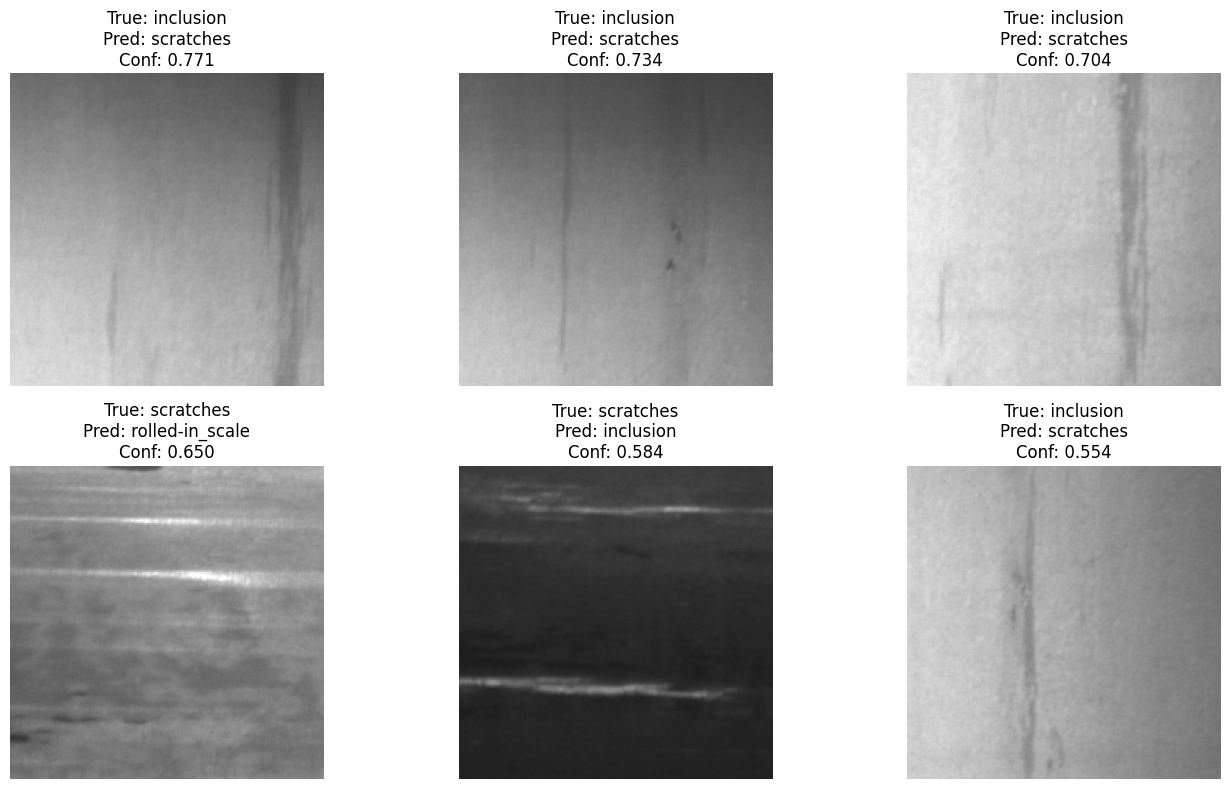

In [47]:
from PIL import Image
import matplotlib.pyplot as plt

top_n = 6
sample_errors = errors_df.head(top_n)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_errors.iterrows()):
    image = Image.open(row["image_path"])

    ax.imshow(image)
    ax.set_title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}\n"
        f"Conf: {row['confidence']:.3f}"
    )
    ax.axis("off")

for ax in axes[len(sample_errors):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
import tensorflow as tf

efficientnet_backbone = champion_model.get_layer("efficientnetb0")

print("Backbone layer name:", efficientnet_backbone.name)
print("Backbone type:", type(efficientnet_backbone).__name__)

conv_layers = [
    layer
    for layer in efficientnet_backbone.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("\nNumber of Conv2D layers:", len(conv_layers))
print("\nLast Conv2D layers inside EfficientNetB0:")

for layer in conv_layers[-10:]:
    print(layer.name, "->", layer.output.shape)

last_conv_layer_name = conv_layers[-1].name

print("\nSelected last conv layer:", last_conv_layer_name)

Backbone layer name: efficientnetb0
Backbone type: Functional

Number of Conv2D layers: 65

Last Conv2D layers inside EfficientNetB0:
block6c_project_conv -> (None, 7, 7, 192)
block6d_expand_conv -> (None, 7, 7, 1152)
block6d_se_reduce -> (None, 1, 1, 48)
block6d_se_expand -> (None, 1, 1, 1152)
block6d_project_conv -> (None, 7, 7, 192)
block7a_expand_conv -> (None, 7, 7, 1152)
block7a_se_reduce -> (None, 1, 1, 48)
block7a_se_expand -> (None, 1, 1, 1152)
block7a_project_conv -> (None, 7, 7, 320)
top_conv -> (None, 7, 7, 1280)

Selected last conv layer: top_conv


In [50]:
import cv2
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt


LAST_CONV_LAYER_NAME = "top_conv"


def make_gradcam_heatmap(image_array, model, backbone, last_conv_layer_name, pred_index=None):
    """
    image_array shape: (1, 224, 224, 3)
    """

    last_conv_layer = backbone.get_layer(last_conv_layer_name)

    # Model from backbone input to both last conv output and backbone final output
    backbone_grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[
            last_conv_layer.output,
            backbone.output,
        ],
    )

    classifier_input = tf.keras.Input(shape=backbone.output.shape[1:])

    x = model.get_layer("global_average_pooling")(classifier_input)
    x = model.get_layer("dropout")(x, training=False)
    classifier_output = model.get_layer("defect_classifier")(x)

    classifier_model = tf.keras.Model(
        inputs=classifier_input,
        outputs=classifier_output,
    )

    # Pass image through augmentation first, then EfficientNet backbone
    augmented_image = model.get_layer("efficientnet_augmentation")(
        image_array,
        training=False,
    )

    with tf.GradientTape() as tape:
        conv_outputs, backbone_outputs = backbone_grad_model(augmented_image)
        predictions = classifier_model(backbone_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()


def overlay_gradcam(image_path, heatmap, alpha=0.40):
    original_image = Image.open(image_path).convert("RGB")
    original_image = original_image.resize((224, 224))

    image_array = np.array(original_image)

    heatmap_resized = cv2.resize(heatmap, (image_array.shape[1], image_array.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    colored_heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colored_heatmap = cv2.cvtColor(colored_heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        image_array,
        1 - alpha,
        colored_heatmap,
        alpha,
        0,
    )

    return image_array, overlay

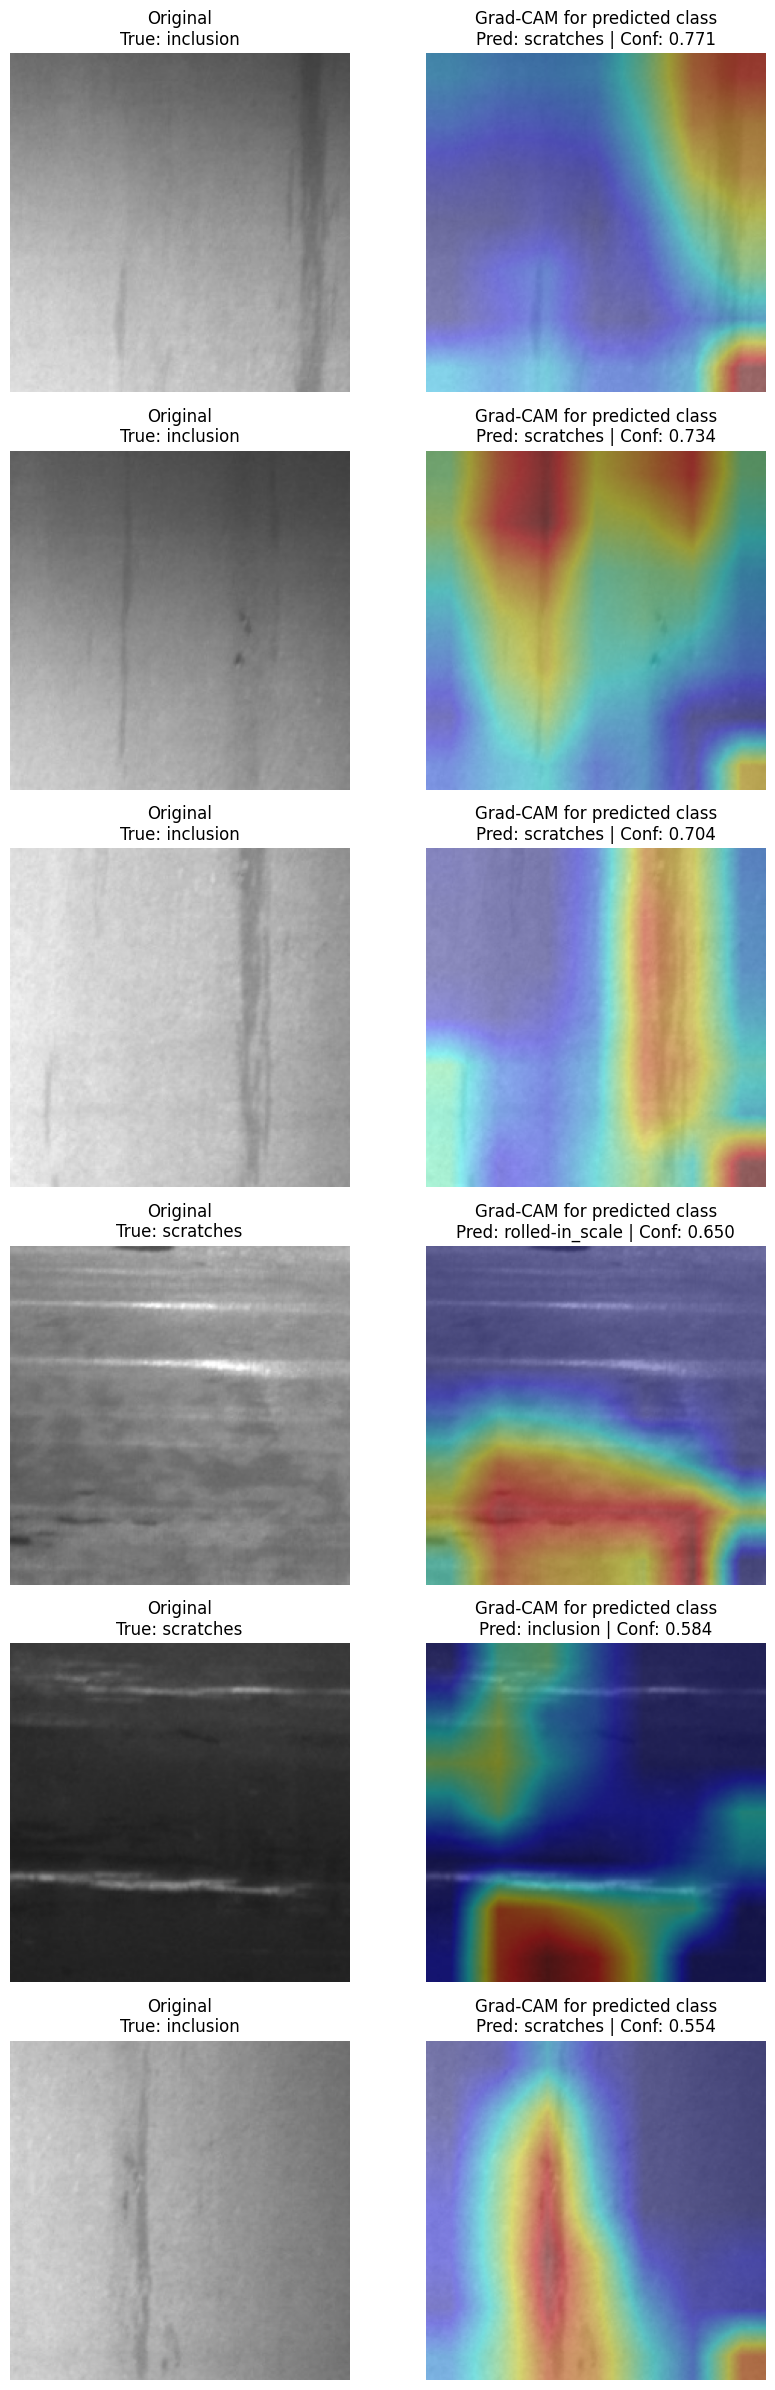

Saved Grad-CAM error analysis to: reports/gradcam_error_analysis/top_error_gradcams.png


In [51]:
from pathlib import Path

gradcam_dir = Path("reports/gradcam_error_analysis")
gradcam_dir.mkdir(parents=True, exist_ok=True)

top_n = 6
sample_errors = errors_df.head(top_n)

fig, axes = plt.subplots(top_n, 2, figsize=(9, 4 * top_n))

for row_index, (_, row) in enumerate(sample_errors.iterrows()):
    image_path = row["image_path"]

    original_image = Image.open(image_path).convert("RGB").resize((224, 224))
    image_array = np.array(original_image).astype("float32")
    image_batch = np.expand_dims(image_array, axis=0)

    predicted_class_index = class_to_index[row["predicted_label"]]

    heatmap = make_gradcam_heatmap(
        image_array=image_batch,
        model=champion_model,
        backbone=efficientnet_backbone,
        last_conv_layer_name=LAST_CONV_LAYER_NAME,
        pred_index=predicted_class_index,
    )

    original, overlay = overlay_gradcam(
        image_path=image_path,
        heatmap=heatmap,
        alpha=0.40,
    )

    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title(
        f"Original\nTrue: {row['true_label']}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(overlay)
    axes[row_index, 1].set_title(
        f"Grad-CAM for predicted class\n"
        f"Pred: {row['predicted_label']} | Conf: {row['confidence']:.3f}"
    )
    axes[row_index, 1].axis("off")

plt.tight_layout()

gradcam_errors_path = gradcam_dir / "top_error_gradcams.png"
plt.savefig(gradcam_errors_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved Grad-CAM error analysis to:", gradcam_errors_path)

In [52]:
confusion_pairs = (
    errors_df.groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print(confusion_pairs)

       true_label  predicted_label  count
0       inclusion        scratches      7
1       scratches  rolled-in_scale      3
2       scratches        inclusion      3
3       inclusion   pitted_surface      2
4  pitted_surface  rolled-in_scale      1


In [53]:
import json

error_analysis_dir = Path("reports/gradcam_error_analysis")
error_analysis_dir.mkdir(parents=True, exist_ok=True)

# Save all wrong predictions
errors_df.to_csv(
    error_analysis_dir / "test_error_predictions.csv",
    index=False,
)

# Save confusion-pair summary
confusion_pairs.to_csv(
    error_analysis_dir / "confusion_pairs.csv",
    index=False,
)

summary = {
    "model": "EfficientNetB0 frozen transfer-learning champion",
    "test_images": int(len(test_df)),
    "correct_predictions": int((y_pred_test == y_true_test).sum()),
    "wrong_predictions": int(len(errors_df)),
    "test_accuracy": 0.9556,
    "test_macro_f1": 0.9550,
    "main_error_patterns": confusion_pairs.to_dict(orient="records"),
    "gradcam_layer": "top_conv",
    "interpretation": (
        "Most errors occurred between visually similar defect classes. "
        "Inclusion defects with long narrow line-like structures were often "
        "classified as scratches. Some scratch samples were confused with "
        "rolled-in scale when the model focused on broader textured regions "
        "instead of thin scratch boundaries."
    ),
    "limitation": (
        "The model performs strongly overall, but remaining failures are "
        "concentrated in visually ambiguous texture patterns between inclusion, "
        "scratches, pitted surface, and rolled-in scale."
    ),
}

with open(error_analysis_dir / "error_analysis_summary.json", "w") as file:
    json.dump(summary, file, indent=2)

print("Saved:")
print(error_analysis_dir / "test_error_predictions.csv")
print(error_analysis_dir / "confusion_pairs.csv")
print(error_analysis_dir / "error_analysis_summary.json")
print(error_analysis_dir / "top_error_gradcams.png")

Saved:
reports/gradcam_error_analysis/test_error_predictions.csv
reports/gradcam_error_analysis/confusion_pairs.csv
reports/gradcam_error_analysis/error_analysis_summary.json
reports/gradcam_error_analysis/top_error_gradcams.png


In [54]:
source = Path("reports/gradcam_error_analysis")
backup_target = Path(
    "/content/drive/MyDrive/surface-scan-mlops/gradcam_error_analysis"
)

if backup_target.exists():
    shutil.rmtree(backup_target)

shutil.copytree(source, backup_target)

print("Grad-CAM report backed up to:")
print(backup_target)

Grad-CAM report backed up to:
/content/drive/MyDrive/surface-scan-mlops/gradcam_error_analysis
